# **AI Based Speaker Classification**

## **Set-Up**

In [139]:
# Base Python libraries
import pandas as pd
import numpy as np
import re
import os
from tqdm import tqdm
import json

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# llm libraries
import ollama
from ollama import Client
import mistralai

### **Load Data**

In [140]:
raw_data = pd.read_csv("data/UWSM_Community_Input_Transcripts_Split.csv")

print("--"*50)
print("Raw Data Shape:")
print(raw_data.shape)
print("--"*50)

----------------------------------------------------------------------------------------------------
Raw Data Shape:
(1769, 11)
----------------------------------------------------------------------------------------------------


In [141]:
# view first few rows
print("--"*50)
print("Raw Data Sample")
print("--"*50)
raw_data

----------------------------------------------------------------------------------------------------
Raw Data Sample
----------------------------------------------------------------------------------------------------


,Source File,Name of Facilitator(s),Date of Conversation,Name of Organization/Group,Meeting Location,Length of Time,Number of Attendees,Population,Summary Keywords,Speaker,Text
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,"This is Pamela, and it's March 17, and I am at..."
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 2,School System. The school system is specific t...
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 3,I think the police department and fire departm...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,Any other strengths have to be specific to Old...
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Pamela Bennett,3/17/26,AVESTA residents,OOB,NaN,8,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Affordable housing, food insecurity, community...",Speaker 1,friendship that we all have. We care for each ...
...,...,...,...,...,...,...,...,...,...,...,...
1764,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 6,like friendship reasons. Can be a friendship r...
1765,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 1,So I'm just gonna read some of the ones we hav...
1766,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 1,"by fast, I know well. Thank you all so so much..."
1767,EFO_YLAT_3-11-26_Nina_Draft.txt,Lee Klarman,"Thu, Mar 12, 2026 12:09PM",YLAT,NaN,51:45,Population - identify one or more of the follo...,"Rural/urban, York/Cumberland/Mix, ALICE(Povert...","Community values, foster care system, mutual a...",Speaker 4,learn more about your organizations? Do you ha...


In [142]:
combined = (
    raw_data.groupby(['Source File', 'Speaker'], sort=False, as_index=False)['Text']
      .agg(' '.join)
)
print("--"*50)
print("Combined Data Sample")
print("--"*50)
combined

----------------------------------------------------------------------------------------------------
Combined Data Sample
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at..."
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the..."
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ..."
...,...,...,...
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit..."
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu..."
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...


In [143]:
combined[combined["Source File"] == "EFO_YLAT_3-11-26_Nina_Draft.txt"]

,Source File,Speaker,Text
181,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 1,"Okay, so this is why lat on March 11, absolute..."
182,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 2,"So the first question that we have for you, it..."
183,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 3,"Just to clarify, are you saying everyone, indi..."
184,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 4,"She wants to just speak out loud, yeah, go for..."
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit..."
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu..."
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...
189,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 9,"I wonder, like, just generally, if we brought ..."


## **Ollama - qwen2.5:14b**

In [144]:
# ---------- Config ----------
MODEL = "qwen2.5:14b"
VALID_LABELS = {"Facilitator", "ALICE", "Above ALICE"}
NON_FACILITATOR_LABELS = {"ALICE", "Above ALICE"}

client = Client(host="http://localhost:11434")

# ---------- Prompt ----------
SYSTEM_PROMPT = """You classify transcript segments into ONE label:

Labels:
1. Facilitator
2. ALICE
3. Above ALICE

Definitions:

Facilitator:
- Asks questions, guides discussion, transitions topics
- Neutral tone, no personal opinions or experiences
- Manages participation or summarizes others
- Does not share personal financial details or struggles

ALICE:
- ALICE stands for Asset Limited, Income Constrained, Employed. This group includes individuals and families who earn above the federal poverty level but struggle to afford basic necessities.
- Describes personal financial struggle or instability
- Mentions bills, rent, food, healthcare, tradeoffs
- Expresses stress, survival, or lack of access to resources

Above ALICE:
- Engages with community issues from a position of stability 
- Concerned, but not personally at risk
- Financially stable or secure
- Talks about savings, investments, homeownership, planning
- May discuss issues abstractly or show concern for others, not self

Decision Rules:
- Pick ONE label only
- If both facilitator + participant appear → choose dominant speaker
- Facilitator cues: asking questions "?", guiding discussion, summarizing others
- If unclear between ALICE vs Above ALICE:
  - Personal struggle → ALICE
  - Stable perspective → Above ALICE
- If unclear or weak signal → choose closest label, confidence ≤ 0.5

Output format (STRICT):
{"label": "<Facilitator|ALICE|Above ALICE>", "confidence": <0.0-1.0>}
"""

NON_FACILITATOR_PROMPT = """Classify the transcript segment into ONE label:

Labels:
- ALICE
- Above ALICE

Definitions:

ALICE:
- ALICE stands for Asset Limited, Income Constrained, Employed. This group includes individuals and families who earn above the federal poverty level but struggle to afford basic necessities.
- Describes personal financial struggle or instability
- Mentions bills, rent, food, healthcare, tradeoffs
- Expresses stress, survival, or lack of access to resources

Above ALICE:
- Engages with community issues from a position of stability 
- Concerned, but not personally at risk
- Financially stable or secure
- Talks about savings, investments, homeownership, planning
- May discuss issues abstractly or show concern for others, not self

Decision Rules:
- Pick ONE label only
- If mixed speakers → classify dominant speaker
- If unsure:
  - Personal struggle → ALICE
  - Stable perspective → Above ALICE
- If weak or unclear → choose closest, confidence ≤ 0.5

Output (STRICT JSON only):
{"label": "<ALICE|Above ALICE>", "confidence": <0.0-1.0>}

"""

In [145]:
def classify_text(text: str, retries: int = 2) -> dict:
    """Classify a single text segment. Returns {'label': str, 'confidence': float}."""
    for attempt in range(retries + 1):
        try:
            response = client.chat(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": f"Classify this text:\n\n{text}"},
                ],
                format="json",            # forces valid JSON output
                options={
                    "temperature": 0,     # deterministic for classification
                    "num_ctx": 4096,      # adjust if your segments are long
                },
            )
            raw = response["message"]["content"]
            parsed = json.loads(raw)
            
            label = parsed.get("label", "").strip()
            confidence = float(parsed.get("confidence", 0.0))
            
            if label not in VALID_LABELS:
                raise ValueError(f"Invalid label returned: {label}")
            
            return {"label": label, "confidence": confidence}
        
        except (json.JSONDecodeError, ValueError, KeyError) as e:
            if attempt == retries:
                return {"label": "ERROR", "confidence": 0.0, "error": str(e)}
            continue

In [146]:
# label and confidence
labels = []
confidences = []

for _, row in tqdm(combined.iterrows(), total=combined.shape[0]):
    text = row["Text"]
    result = classify_text(text)
    labels.append(result["label"])
    confidences.append(result["confidence"])

# Add results to combined DataFrame
combined["Predicted Label"] = labels
combined["Confidence"] = confidences


100%|██████████| 190/190 [29:50<00:00,  9.42s/it] 


In [147]:
combined

,Source File,Speaker,Text,Predicted Label,Confidence
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at...",Facilitator,1.00
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,0.75
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Above ALICE,0.80
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,1.00
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,0.70
...,...,...,...,...,...
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit...",ALICE,0.95
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...,Facilitator,0.90
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu...",Above ALICE,0.80
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...,ALICE,0.85


**Resolving Duel Facilitator Ambiguity**

In [148]:
def alice_non_alice(text: str, retries: int = 2) -> dict:
    """Classify a single text segment. Returns {'label': str, 'confidence': float}."""
    for attempt in range(retries + 1):
        try:
            response = client.chat(
                model=MODEL,
                messages=[
                    {"role": "system", "content": NON_FACILITATOR_PROMPT},
                    {"role": "user", "content": f"Classify this text:\n\n{text}"},
                ],
                format="json",            # forces valid JSON output
                options={
                    "temperature": 0,     # deterministic for classification
                    "num_ctx": 4096,      # adjust if your segments are long
                },
            )
            raw = response["message"]["content"]
            parsed = json.loads(raw)
            
            label = parsed.get("label", "").strip()
            confidence = float(parsed.get("confidence", 0.0))
            
            if label not in VALID_LABELS:
                raise ValueError(f"Invalid label returned: {label}")
            
            return {"label": label, "confidence": confidence}
        
        except (json.JSONDecodeError, ValueError, KeyError) as e:
            if attempt == retries:
                return {"label": "ERROR", "confidence": 0.0, "error": str(e)}
            continue

**Solving Multiple Facilitator Issue**

In [149]:
for source in combined["Source File"].unique():

    mask = (
        (combined["Source File"] == source) &
        (combined["Predicted Label"] == "Facilitator")
    )

    subset = combined.loc[mask]

    if len(subset) <= 1:
        continue  # Already fine, skip

    # Find the single best Facilitator
    best_idx = subset["Confidence"].idxmax()

    # Every other Facilitator in this file gets re-evaluated
    other_indices = [idx for idx in subset.index if idx != best_idx]

    for idx in other_indices:
        text = combined.loc[idx, "Text"]
        result = alice_non_alice(text)

        combined.loc[idx, "Predicted Label"] = result["label"]
        combined.loc[idx, "Confidence"] = result["confidence"]

**Solving ALICE vs Above-ALICE Ambiguity**

In [150]:
mask = (
    (combined["Predicted Label"] == "Above ALICE") &
    (combined["Confidence"] < 0.5)
)

indices = combined.index[mask]

for idx in indices:
    text = combined.loc[idx, "Text"]
    result = alice_non_alice(text)

    combined.loc[idx, "Predicted Label"] = result["label"]
    combined.loc[idx, "Confidence"] = result["confidence"]

In [151]:
combined.to_csv("data/UWSM_Combined_Labeled.csv", index=False)

In [152]:
combined

,Source File,Speaker,Text,Predicted Label,Confidence
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at...",Facilitator,1.00
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,0.75
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Above ALICE,0.80
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,1.00
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,0.70
...,...,...,...,...,...
185,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 5,"I think, when I think about the lilac communit...",ALICE,0.95
186,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 6,a real it's a real challenge. Do you like abou...,Above ALICE,0.20
187,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 7,"meaning, I would say that's about a person, bu...",Above ALICE,0.80
188,EFO_YLAT_3-11-26_Nina_Draft.txt,Speaker 8,similar to what I was going what I was going t...,ALICE,0.85


**Santity Check**

In [153]:
len(combined[combined["Predicted Label"] == "Facilitator"])

24

In [154]:
for count, source in enumerate(combined["Source File"].unique()):
    print(f"{count}: Source File: {source}")
    subset = combined[(combined["Source File"] == source) & (combined["Predicted Label"] == "Facilitator")]
    print(subset[["Speaker", "Confidence"]])
    print("--"*50)


0: Source File: EFO_AvestaOOB_York County, Older Adults, Renters.txt
     Speaker  Confidence
0  Speaker 1         1.0
----------------------------------------------------------------------------------------------------
1: Source File: EFO_Bartlett Woods_York County, Older Adults, Urban, ALICE.txt
     Speaker  Confidence
9  Speaker 1         1.0
----------------------------------------------------------------------------------------------------
2: Source File: EFO_Biddeford Resiliency_York County, Under 25, Rural, Serves ALICE.txt
      Speaker  Confidence
18  Speaker 1         1.0
----------------------------------------------------------------------------------------------------
3: Source File: EFO_BridgtonLibrary_Cumberland County, Rural, Some ALICE.txt
      Speaker  Confidence
26  Speaker 1         1.0
----------------------------------------------------------------------------------------------------
4: Source File: EFO_ELU 2-18-2026 Val - Cumberland County, Urban, Above ALICE, 

### **Prediction Distribution**

In [155]:
summary = (
    combined
    .groupby("Predicted Label")
    .agg(
        mean_confidence=("Confidence", "mean"),
        frequency=("Predicted Label", "count")
    )
    .reset_index()
)

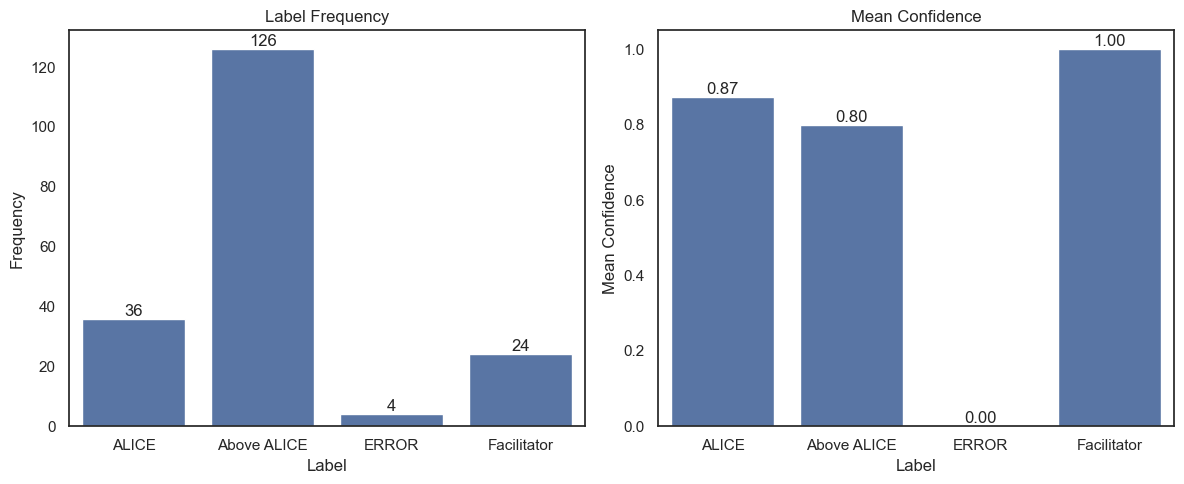

In [156]:
sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Frequency Plot ---
sns.barplot(
    data=summary,
    x="Predicted Label",
    y="frequency",
    ax=axes[0]
)

axes[0].set_title("Label Frequency")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Frequency")

# Add value labels
for i, v in enumerate(summary["frequency"]):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# --- Mean Confidence Plot ---
sns.barplot(
    data=summary,
    x="Predicted Label",
    y="mean_confidence",
    ax=axes[1]
)

axes[1].set_title("Mean Confidence")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Mean Confidence")

# Add value labels
for i, v in enumerate(summary["mean_confidence"]):
    axes[1].text(i, v, f"{v:.2f}", ha='center', va='bottom')

# Remove gridlines explicitly (extra safety)
for ax in axes:
    ax.grid(False)

plt.tight_layout()
plt.show()

In [157]:
alice_subset = combined[combined["Predicted Label"] == "ALICE"]
above_alice_subset = combined[combined["Predicted Label"] == "Above ALICE"]

In [158]:
print("--"*50)
print("ALICE Subset Shape:")
print(alice_subset.shape)
print("--"*50)
alice_subset.head(10)

----------------------------------------------------------------------------------------------------
ALICE Subset Shape:
(36, 5)
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text,Predicted Label,Confidence
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,1.00
14,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 6,Avesta never took charge. That's true. We just...,ALICE,0.80
16,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 9,"You get a hold of Jean, okay? What she does is...",ALICE,0.80
24,"EFO_Biddeford Resiliency_York County, Under 25...",Speaker 7,"Uh, another thing I think that help that we do...",ALICE,0.90
29,"EFO_BridgtonLibrary_Cumberland County, Rural, ...",Speaker 4,I always really appreciate that people are wil...,ALICE,0.90
33,"EFO_BridgtonLibrary_Cumberland County, Rural, ...",Speaker 8,"Yeah, the sense of community is very clear. Th...",ALICE,0.80
36,"EFO_ELU 2-18-2026 Val - Cumberland County, Urb...",Speaker 3,"I can start, I would say in terms of thinking ...",ALICE,0.95
44,"EFO_GreatBay_3-3_York County, Rural, Some ALIC...",Speaker 4,"Kind of like, gets around, like, very fast her...",ALICE,0.85
46,"EFO_GreatBay_3-3_York County, Rural, Some ALIC...",Speaker 6,"Well, just to go back on the mode of care issu...",ALICE,0.80
56,"EFO_MAIN_Cumberland, Urban, Immigrants, ALICE.txt",Speaker 2,Do you have something like that on your websit...,ALICE,0.90


----------------------------------------------------------------------------------------------------
Confidence Distribution for ALICE:
----------------------------------------------------------------------------------------------------


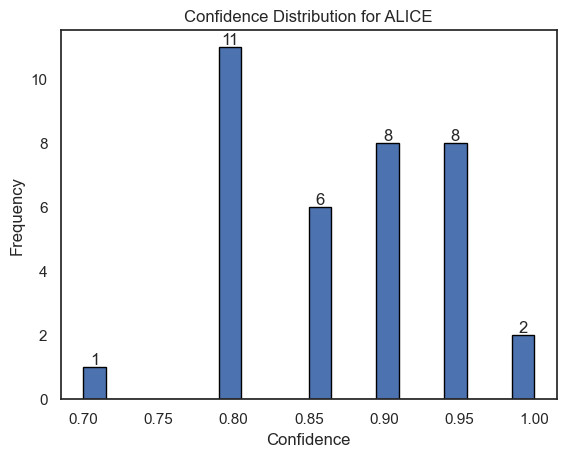

In [165]:
# Alice Category Distribution
print("--"*50)
print("Confidence Distribution for ALICE:")
print("--"*50)

sns.set_style("white")  # remove grid

fig, ax = plt.subplots()

# Plot histogram
counts, bins, patches = ax.hist(alice_subset["Confidence"], bins=20, edgecolor='black')

# Add frequency labels on top of bars
for count, patch in zip(counts, patches):
    if count > 0:  # avoid cluttering zeros
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom'
        )

ax.set_title("Confidence Distribution for ALICE")
ax.set_xlabel("Confidence")
ax.set_ylabel("Frequency")

ax.grid(False)  # ensure no grid

plt.show()

In [160]:
print("--"*50)
print("Above ALICE Subset Shape:")
print(above_alice_subset.shape)
print("--"*50)
above_alice_subset.head(10)

----------------------------------------------------------------------------------------------------
Above ALICE Subset Shape:
(126, 5)
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text,Predicted Label,Confidence
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,0.75
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Above ALICE,0.80
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,0.70
5,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 8,We never go to the movie or anything. People a...,Above ALICE,0.80
6,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 5,"gas in your car, or electricity bill. You've g...",Above ALICE,0.70
7,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 7,"Did you smell it the other day, that warm day ...",Above ALICE,0.80
8,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 10,"I was saying, When are my kids are young, but ...",Above ALICE,0.80
10,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 2,I lived in Yarmouth most of my life. I owned h...,Above ALICE,0.85
11,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 3,I find it an extraordinarily friendly communit...,Above ALICE,0.90
12,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 4,"I think that's true, that there are a lot more...",Above ALICE,0.90


----------------------------------------------------------------------------------------------------
Confidence Distribution for ABOVE ALICE:
----------------------------------------------------------------------------------------------------


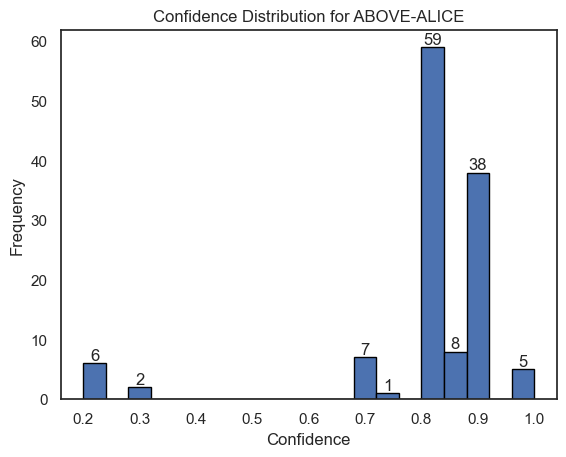

In [167]:
print("--"*50)
print("Confidence Distribution for ABOVE ALICE:")
print("--"*50)
sns.set_style("white")  # remove grid

fig, ax = plt.subplots()

# Plot histogram
counts, bins, patches = ax.hist(above_alice_subset["Confidence"], bins=20, edgecolor='black')

# Add frequency labels on top of bars
for count, patch in zip(counts, patches):
    if count > 0:  # avoid cluttering zeros
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom'
        )

ax.set_title("Confidence Distribution for ABOVE-ALICE")
ax.set_xlabel("Confidence")
ax.set_ylabel("Frequency")

ax.grid(False)  # ensure no grid

plt.show()

## **BERTopic Pipeline**

**Loading Important Libraires**

In [189]:
# Stopwords for text preprocessing
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords

# NLP and topic modeling libraries
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Supporting libraries
import torch
import gc
import time

**BGE-Large Embedding Generation**

In [190]:
# BGE M3 Implementation Code
bge_large = SentenceTransformer('BAAI/bge-large-en-v1.5')

print("--"*50)
print("BGE Large Model Loaded Successfully !!")
print("--"*50)
print("Model Details:")
print(f"Model loaded: BAAI/bge-large-en-v1.5")
print(f"Max sequence length: {bge_large.max_seq_length}")
print(f"Embedding dimension: {bge_large.get_sentence_embedding_dimension()}")
print(f"Number of layers: {len(bge_large[0].auto_model.encoder.layer)}")
print(f"Vocabulary size: {bge_large[0].auto_model.config.vocab_size}")
print("--"*50)

----------------------------------------------------------------------------------------------------
BGE Large Model Loaded Successfully !!
----------------------------------------------------------------------------------------------------
Model Details:
Model loaded: BAAI/bge-large-en-v1.5
Max sequence length: 512
Embedding dimension: 1024
Number of layers: 24
Vocabulary size: 30522
----------------------------------------------------------------------------------------------------


**Defining UMAP**

In [191]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
)


**Defining HDBSCAN**

In [192]:
hdbscan_model = HDBSCAN(
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

**Vector Model**

In [193]:
# Remove English stopwords at the c-TF-IDF stage, not before embedding
vectorizer_model = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2),  # include bigrams — "food bank", "mental health"
)

**BERTopic Pipeline**

In [194]:
# Use a powerful sentence transformer for better embeddings
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=bge_large,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    calculate_probabilities=False,
    verbose=True,
)

**WordCloud**

In [195]:
def wordcloud_for_topic(topic_model, topic_id):
    words = dict(topic_model.get_topic(topic_id))  # {word: c-tf-idf score}
    if not words:
        return None
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='viridis',
    ).generate_from_frequencies(words)
    return wc

### **Defining and Cleaning text corpus**

In [196]:
# Cleanup to cleaning the conversations: removing extra spaces, newlines, and tabs
def clean_text(text):

    # Remove special characters and numbers, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'[\n\r\t]+', ' ', text)

    # Convert to lowercase
    text = text.lower()
    return text

In [197]:
# Apllying clean text function
combined["clean_text"] = combined["Text"].apply(clean_text)

print("--"*50)
print("Cleaned Text Sample:")
print("--"*50)
combined.head(10)

----------------------------------------------------------------------------------------------------
Cleaned Text Sample:
----------------------------------------------------------------------------------------------------


,Source File,Speaker,Text,Predicted Label,Confidence,clean_text
0,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 1,"This is Pamela, and it's March 17, and I am at...",Facilitator,1.00,this is pamela and its march 17 and i am at av...
1,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 2,School System. The school system is specific t...,Above ALICE,0.75,school system the school system is specific to...
2,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 3,I think the police department and fire departm...,Above ALICE,0.80,i think the police department and fire departm...
3,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 4,"No Everybody minds their own business, but the...",ALICE,1.00,no everybody minds their own business but they...
4,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 6,"There's a lot of places to go walking, if you ...",Above ALICE,0.70,theres a lot of places to go walking if you oh...
5,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 8,We never go to the movie or anything. People a...,Above ALICE,0.80,we never go to the movie or anything people ar...
6,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 5,"gas in your car, or electricity bill. You've g...",Above ALICE,0.70,gas in your car or electricity bill youve got ...
7,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 7,"Did you smell it the other day, that warm day ...",Above ALICE,0.80,did you smell it the other day that warm day t...
8,"EFO_AvestaOOB_York County, Older Adults, Rente...",Speaker 10,"I was saying, When are my kids are young, but ...",Above ALICE,0.80,i was saying when are my kids are young but wh...
9,"EFO_Bartlett Woods_York County, Older Adults, ...",Speaker 1,"As a reminder, I'm going to start by asking on...",Facilitator,1.00,as a reminder im going to start by asking one ...


In [198]:
docs = combined["clean_text"].tolist()

### **Training BGE-Large Model**

In [199]:
# BGE-Large Embedding Generation
start_time = time.time()

try:
    dvc = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
    )

    bge_large_embeddings = bge_large.encode(
    docs,
    batch_size=16,              # Small dataset, no need to go higher
    show_progress_bar=True,
    normalize_embeddings=True,  # CRITICAL — BGE explicitly requires this for cosine similarity
    device=dvc,
    convert_to_numpy=True,      # BERTopic expects numpy, not tensors
    chunk_size=None,            # Let it handle full docs, don't chunk
    )


except Exception as e:
    print(f"Error occurred: {e}")

elapsed = time.time() - start_time

print(f"\nDone in {elapsed:.1f} seconds ({len(docs)/elapsed:.1f} docs/sec)")
print(f"Embedding matrix shape: {bge_large_embeddings.shape}")

Batches: 100%|██████████| 12/12 [00:15<00:00,  1.33s/it]


Done in 16.0 seconds (11.9 docs/sec)
Embedding matrix shape: (190, 1024)


### **Question Map Pipeline**


Running BERTopic: ALICE → Strengths (13 docs)


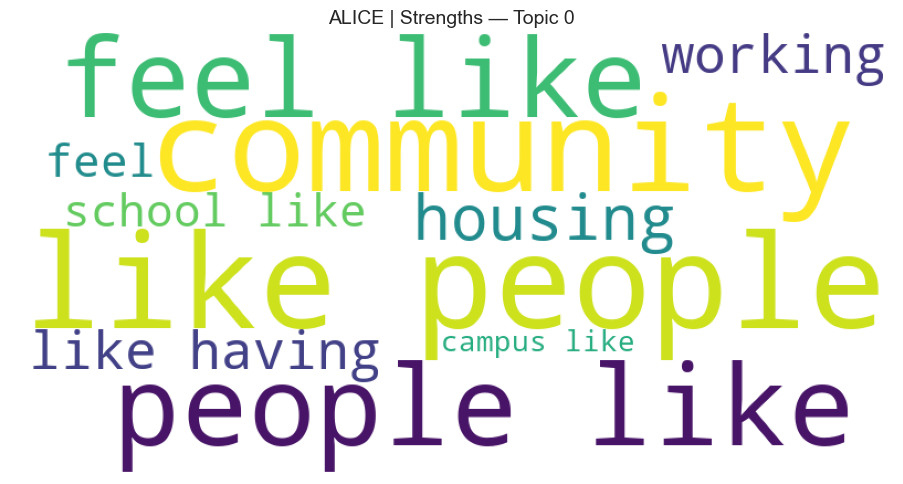

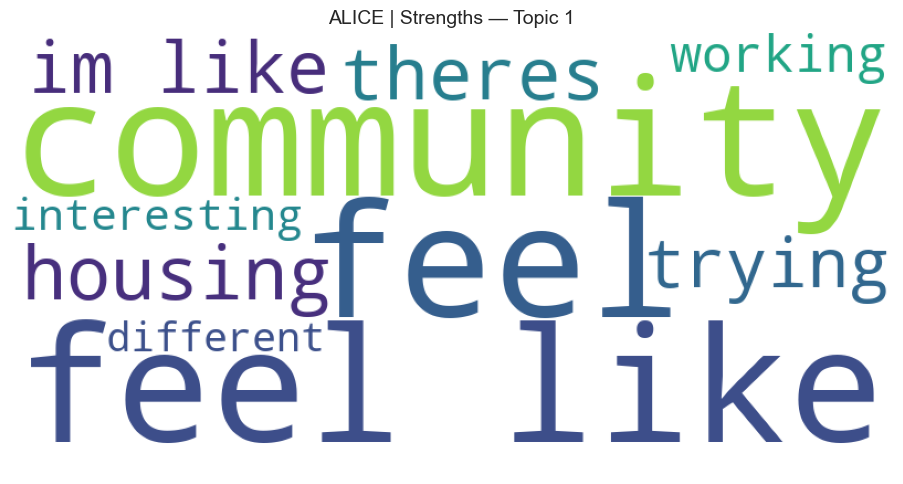


Running BERTopic: ALICE → Challenges (22 docs)

Running BERTopic: ALICE → Aspirations (28 docs)


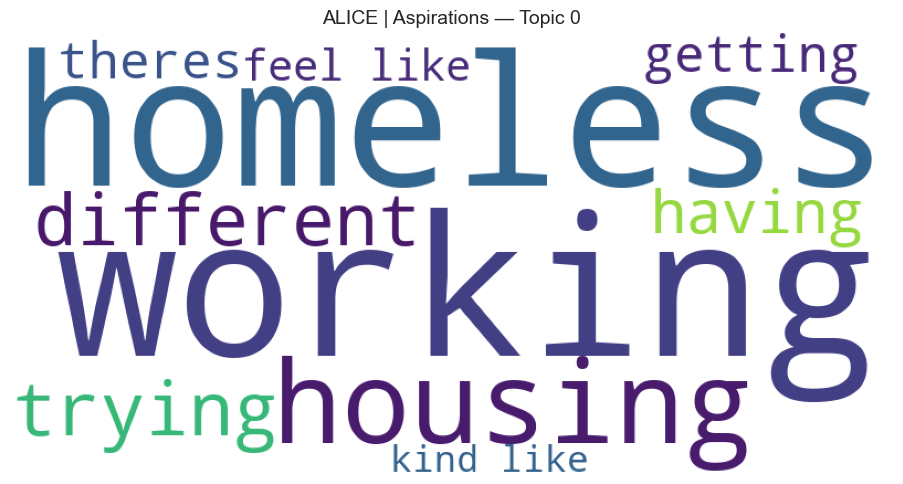

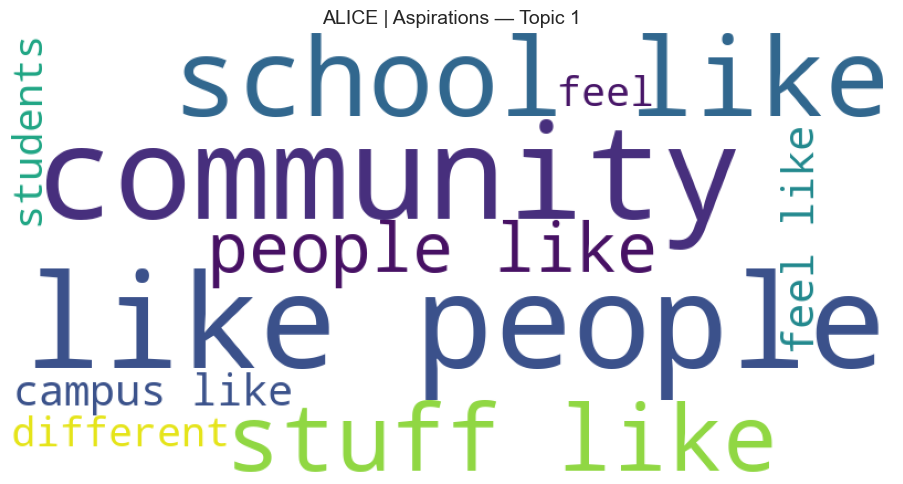

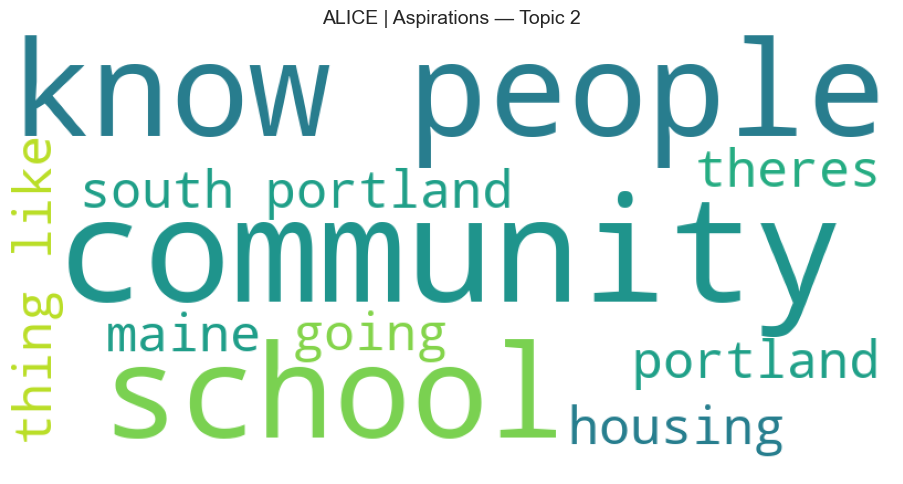


Running BERTopic: ALICE → Actions (35 docs)


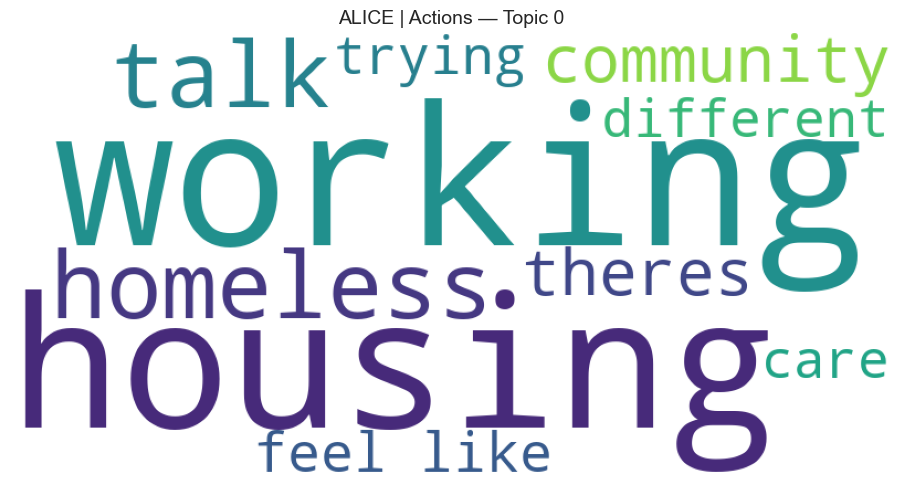

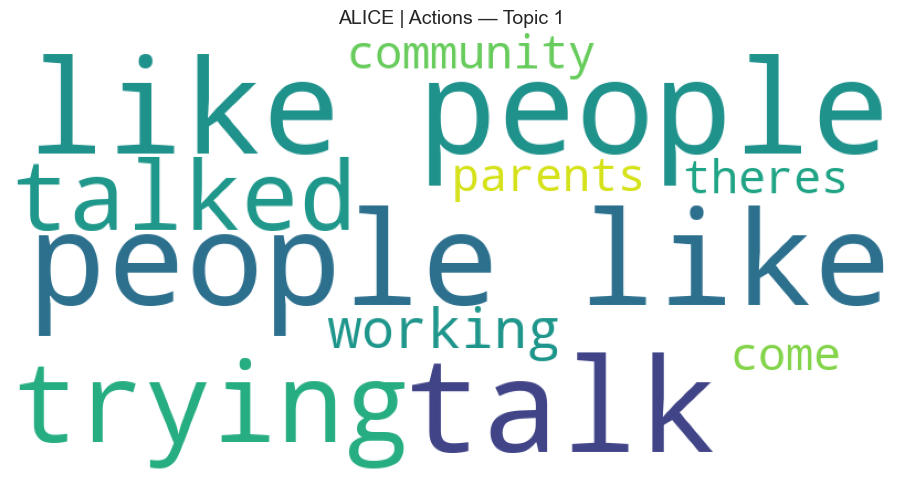

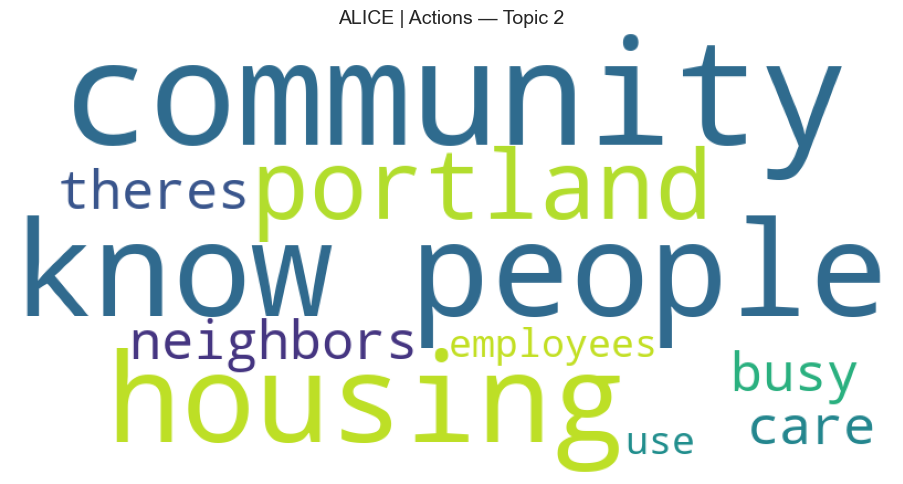


Running BERTopic: Above_ALICE → Strengths (64 docs)


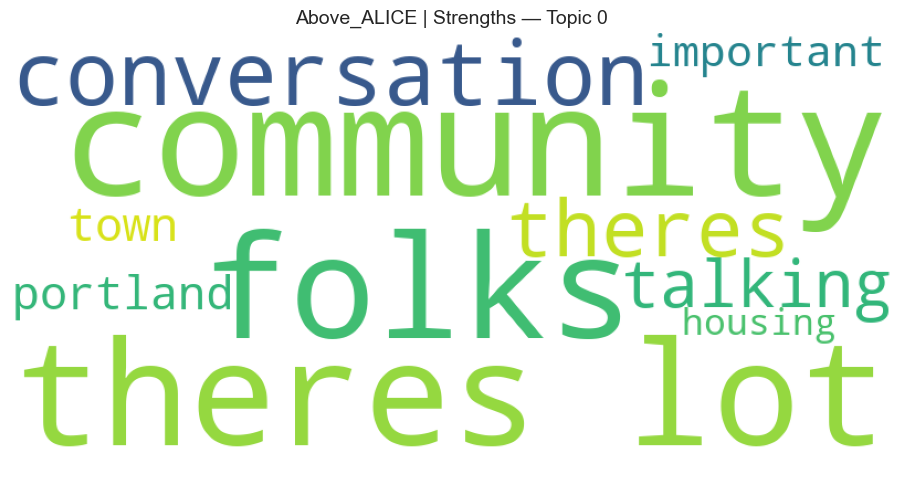

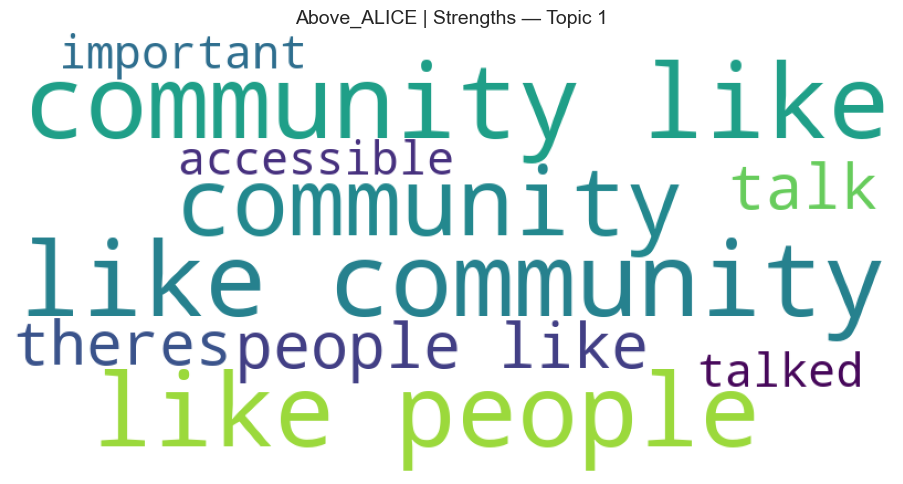

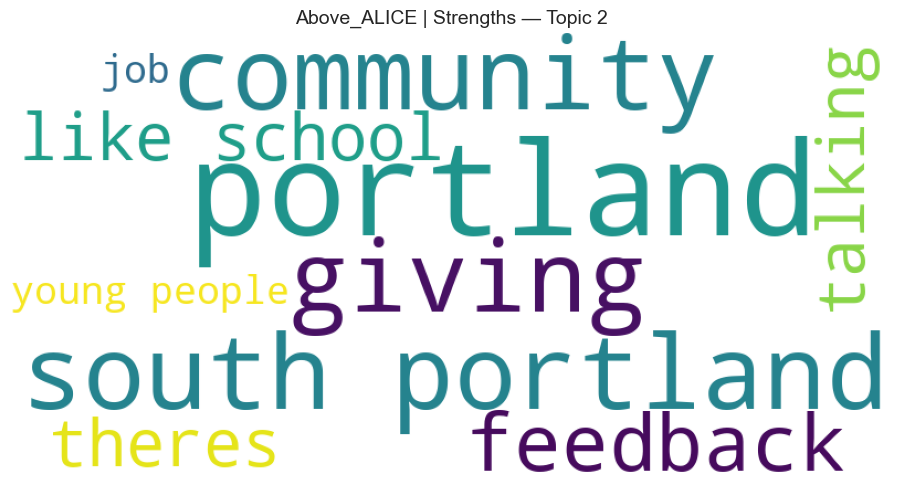

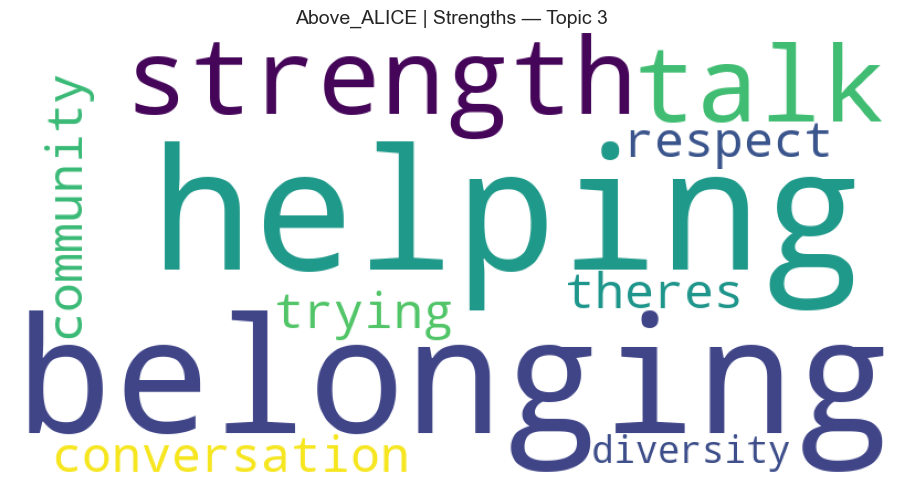


Running BERTopic: Above_ALICE → Challenges (71 docs)


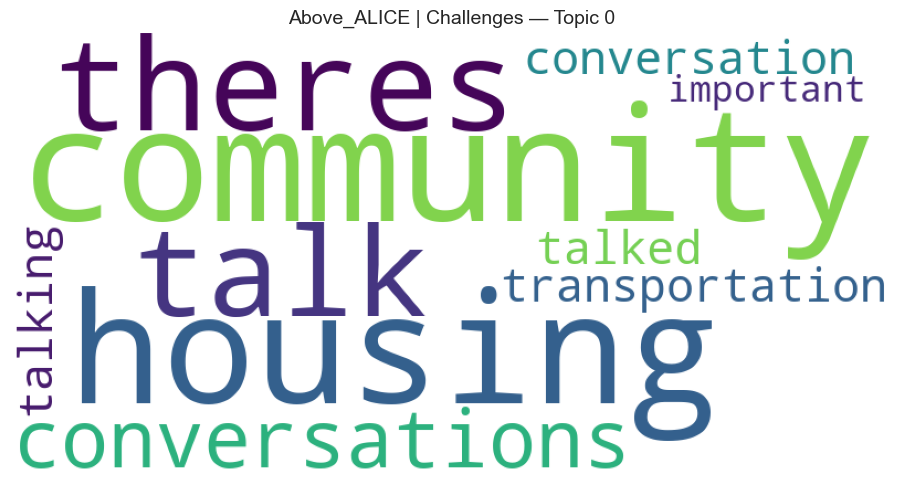

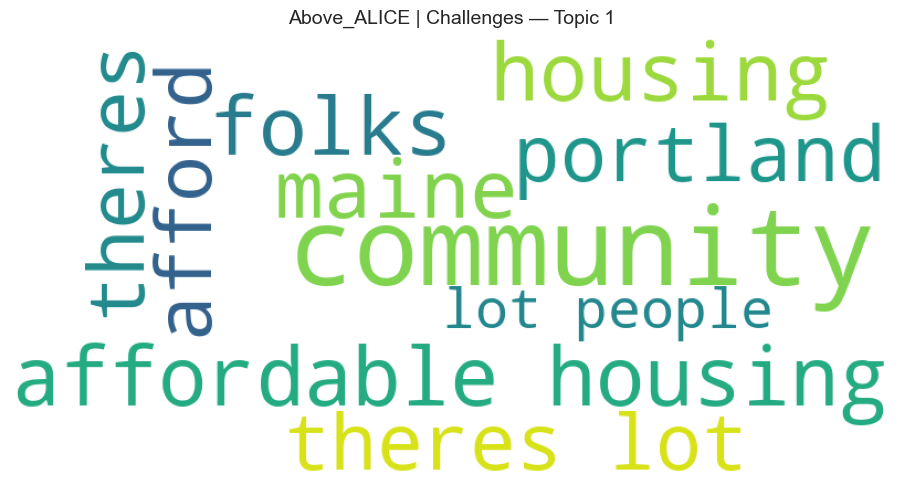

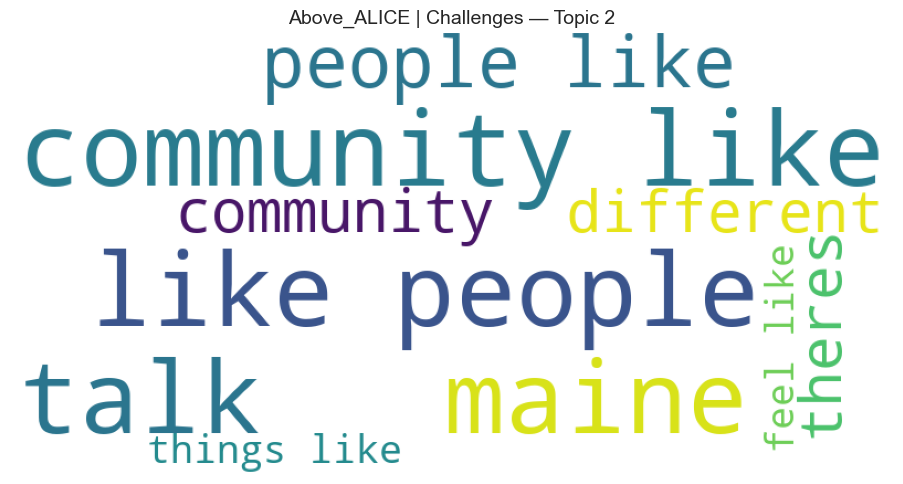

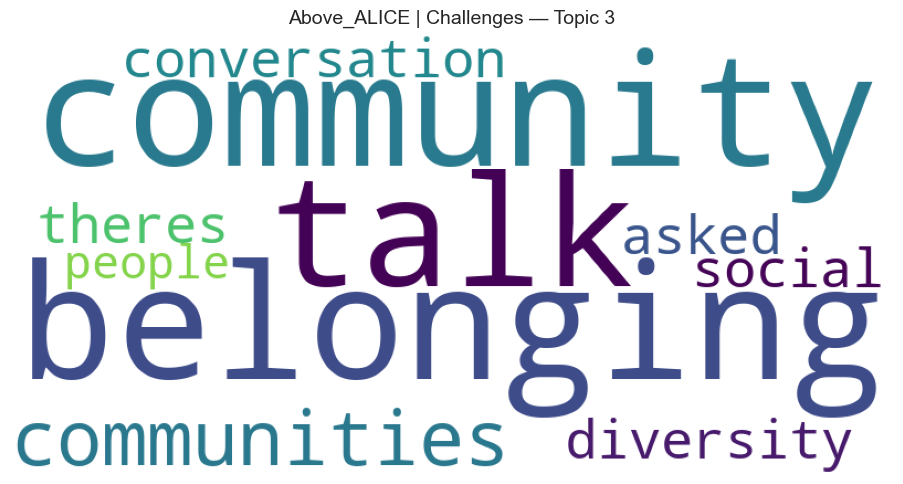


Running BERTopic: Above_ALICE → Aspirations (100 docs)


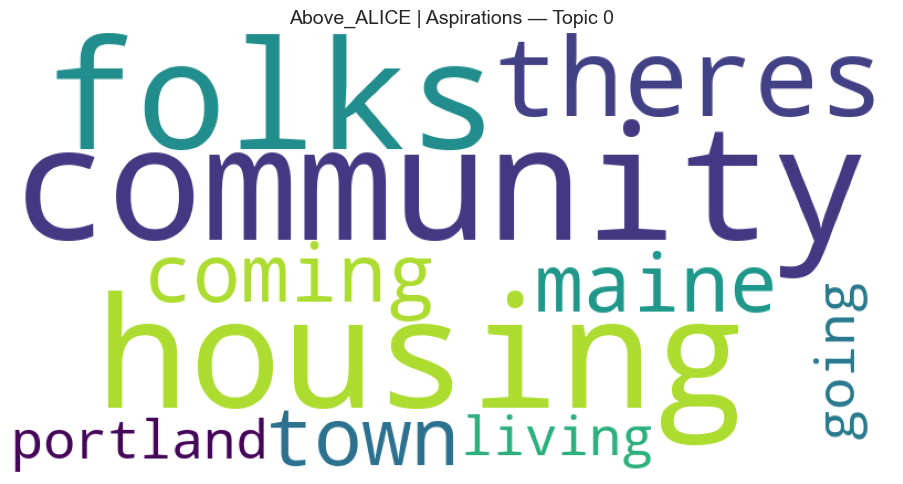

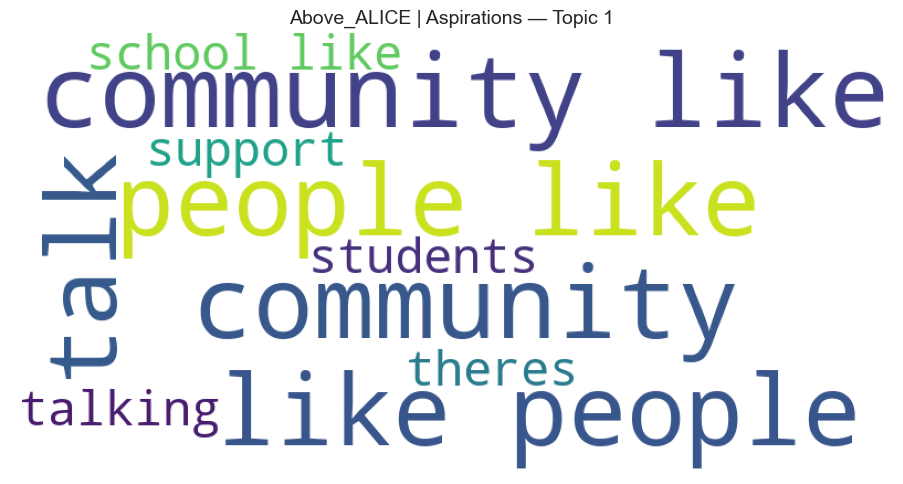

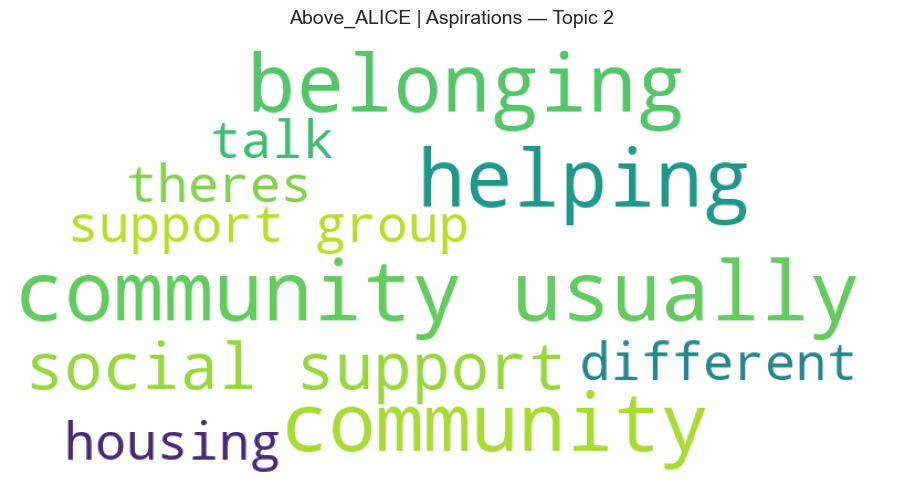


Running BERTopic: Above_ALICE → Actions (115 docs)


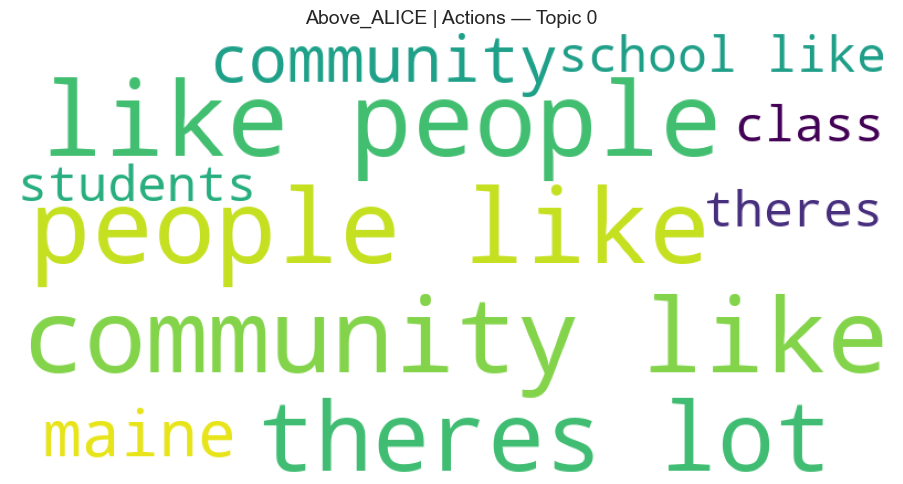

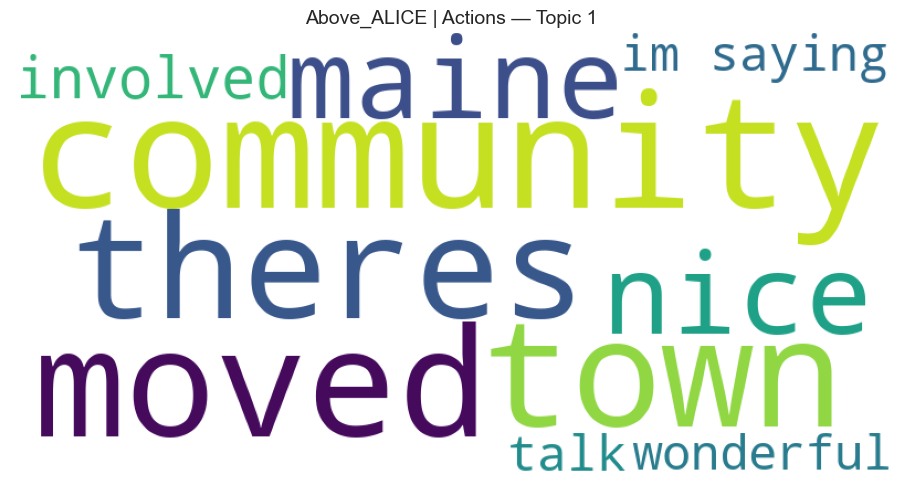

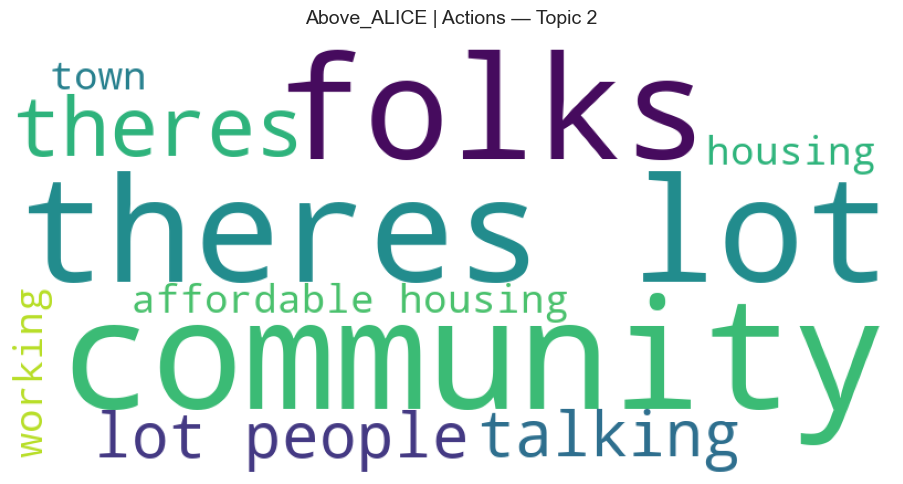

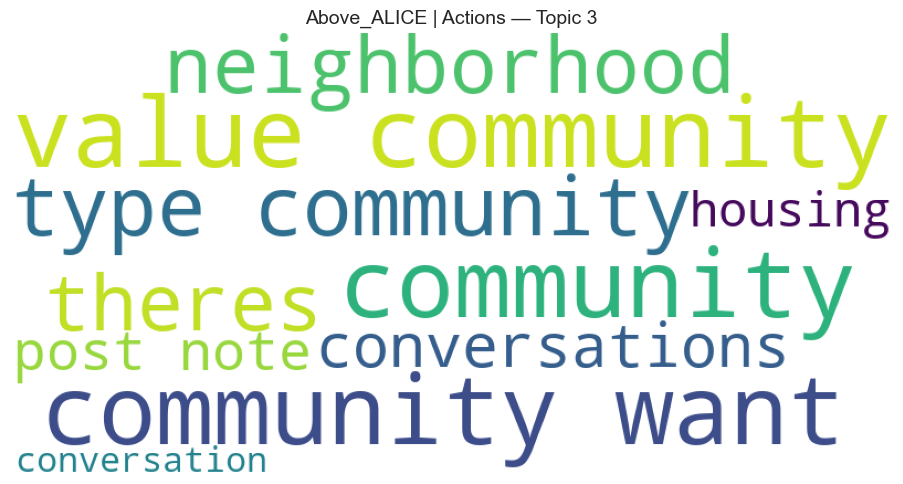

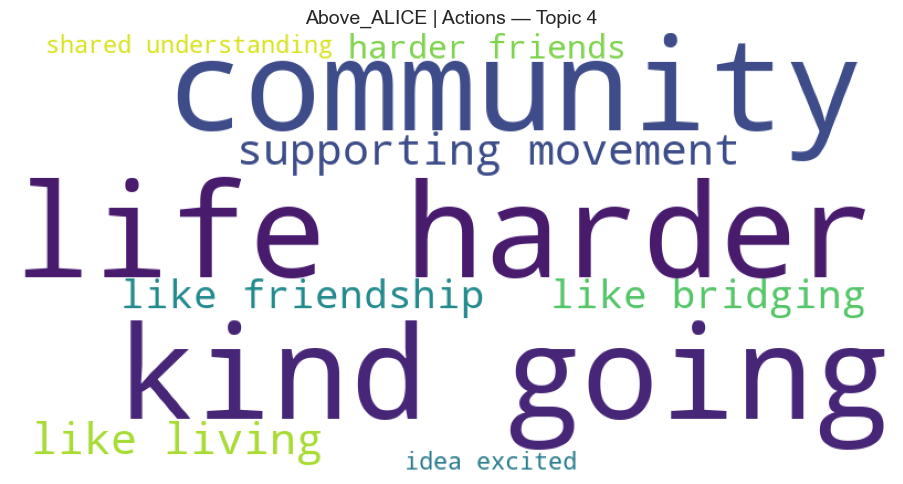

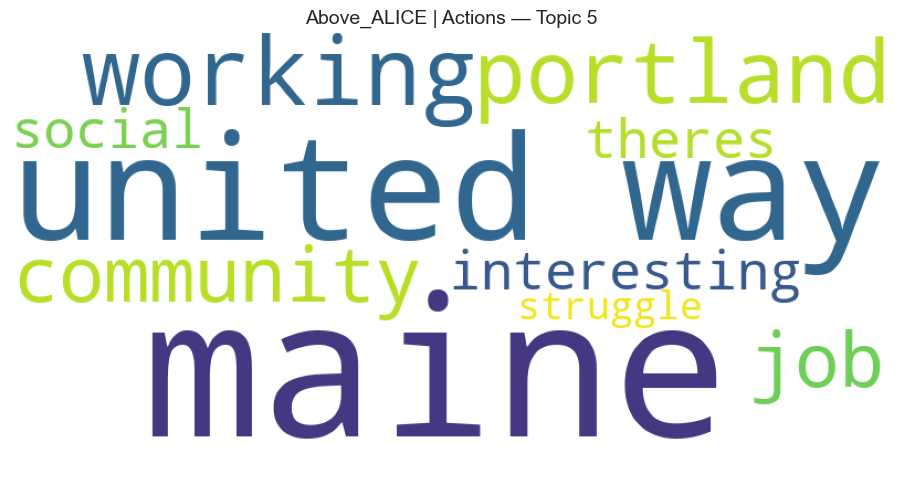

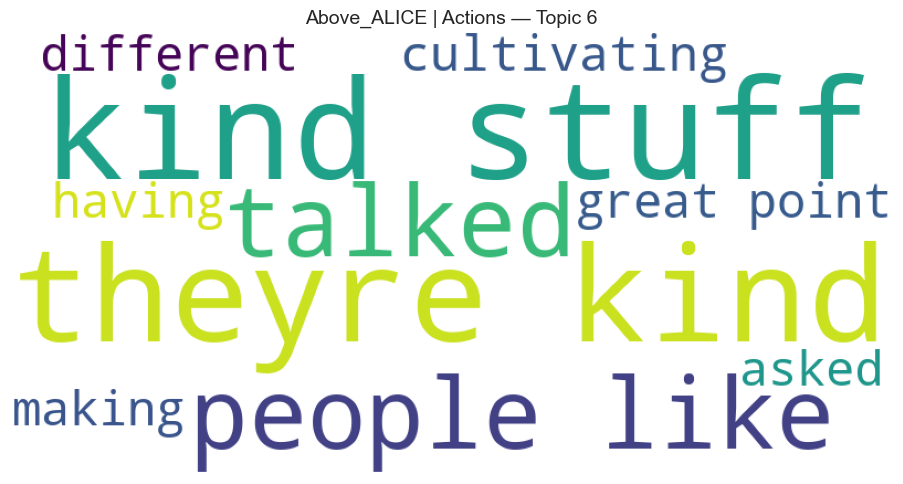

In [203]:
# Summary Analysis Question Keywords
import os
from sklearn.feature_extraction.text import CountVectorizer

question_map = {
    "Strengths": ["strength", "value", "resource", "helpful", "accessible"],
    "Challenges": ["hard", "struggle", "barrier", "difficult", "problem"],
    "Aspirations": ["want", "wish", "hope", "dream", "future", "community"],
    "Actions": ["should", "could", "need to", "improve", "make", "do"]
}

# Create wordcloud directory if it doesn't exist
os.makedirs("wordcloud", exist_ok=True)

# Create subsets for ALICE and Above ALICE
alice_subset = combined[combined["Predicted Label"] == "ALICE"]
above_alice_subset = combined[combined["Predicted Label"] == "Above ALICE"]

# Your three dataframes
group_map = {
    "ALICE": alice_subset,
    "Above_ALICE": above_alice_subset,
}

results = {}

for group_name, df in group_map.items():
    results[group_name] = {}

    for category, keywords in question_map.items():

        mask = df["clean_text"].str.contains(
            "|".join(keywords), case=False, na=False
        )
        corpus = df.loc[mask, "clean_text"].tolist()

        if len(corpus) < 5:
            print(f"Skipping {group_name} → {category} — only {len(corpus)} docs, insufficient")
            continue

        print(f"\nRunning BERTopic: {group_name} → {category} ({len(corpus)} docs)")

        # Use fractional min_df (proportion) instead of absolute count
        # This automatically scales with corpus size and avoids vectorizer conflicts
        # min_df=0.1 means term must appear in at least 10% of documents
        vectorizer_small = CountVectorizer(
            stop_words='english',
            min_df=0.1,  # 10% of documents (more robust for small corpora)
            ngram_range=(1, 2),
        )
        
        # Create a temporary BERTopic model with adjusted vectorizer
        topic_model_temp = BERTopic(
            embedding_model=bge_large,
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer_small,
            representation_model=representation_model,
            calculate_probabilities=False,
            verbose=False,  # Reduce noise from temporary model
        )

        topics, _ = topic_model_temp.fit_transform(corpus)

        results[group_name][category] = {
            "corpus": corpus,
            "topics": topics,
            "topic_info": topic_model_temp.get_topic_info()
        }

        # WordCloud per topic
        for topic_id in set(topics):
            if topic_id == -1:
                continue
            wc = wordcloud_for_topic(topic_model_temp, topic_id)
            if wc:
                plt.figure(figsize=(10, 5))
                plt.title(f"{group_name} | {category} — Topic {topic_id}", fontsize=14)
                plt.imshow(wc)
                plt.axis("off")
                plt.tight_layout()
                plt.savefig(f"wordcloud/wc_{group_name}_{category}_topic{topic_id}.png", dpi=150)
                plt.show()